In [1]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

# Добавляем CSS для глобального применения прокрутки к графикам
display(HTML("""
    <style>
        .scrollable-output {
            max-height: 300px;
            overflow-y: auto;
            border: 1px solid #ddd;
            padding: 5px;
        }
    </style>
"""))

def scrollable_plot(fig, height=400):
    """Выводит matplotlib figure в прокручиваемом контейнере"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.getvalue()).decode()
    
    html = f"""
    <div class="scrollable-output" style="max-height: {height}px;">
        <img src="data:image/png;base64,{img_base64}">
    </div>
    """
    plt.close(fig)  # Закрываем фигуру, чтобы избежать двойного вывода
    display(HTML(html))

# Пример использования
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(10), range(10))
# scrollable_plot(fig)


In [3]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
plt.rcParams["image.cmap"] = 'magma'
import seaborn as sns
from tqdm.notebook import tqdm
from tabulate import tabulate

from damo.config.base import parse_config
from damo.detectors.detector import build_local_model
from damo.base_models.core.ops import RepConv

from my_help_functions.hooks import register_hooks_batch_forward

In [3]:
def load_images_from_folder(folder):
    img_list = []
    names = []
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(".jpg"):
            path = os.path.join(folder, filename)
            img = cv2.imread(path)
            if img is not None:
                img_list.append(img)
                names.append(filename)
    return img_list, names

def load_images_from_folder_coco(folder):
    img_list = []
    names = []
    i = 0
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(".jpg"):
            path = os.path.join(folder, filename)
            img = cv2.imread(path)
            if img is not None:
                img_list.append(img)
                names.append(filename.split('.')[0])
        i += 1
        if i == 64: break
    return img_list, names

In [4]:
from damo.dataset.transforms import transforms as T
from damo.structures.image_list import to_image_list

def transform_img_(origin_img, size_divisibility=0, image_max_range=(640, 640), flip_prob=0.0,
                  image_mean=[0.0, 0.0, 0.0], image_std=[1.0, 1.0, 1.0], keep_ratio=False, infer_size=[640,640]):
    transform = [
        T.Resize(image_max_range, target_size=infer_size, keep_ratio=keep_ratio),
        T.RandomHorizontalFlip(flip_prob),
        T.ToTensor(),
        T.Normalize(mean=image_mean, std=image_std),
    ]
    transform = T.Compose(transform)

    img, _ = transform(origin_img)
    img = to_image_list(img, size_divisibility)
    return img

In [5]:
def run_batch_inference(config_path, ckpt_path, img_folder, model_desired_layers, device='cuda'):
    config = parse_config(config_path)
    model = build_local_model(config, device)
    model.to(device)

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'], strict=True)
    layer_outputs_fwd = register_hooks_batch_forward(model, model_desired_layers)

    model.eval()

    global coco_
    imgs, names = load_images_from_folder_coco(img_folder) if coco_ else load_images_from_folder(img_folder)

    # Трансформация + сохранение размеров
    transformed = []
    shapes = []  # (h0, w0, h1, w1)
    for img in imgs:
        h0, w0 = img.shape[:2]
        img_t = transform_img_(img)
        h1, w1 = img_t.tensors.shape[-2:]
        transformed.append(img_t)
        shapes.append((h0, w0, h1, w1))

    image_list = torch.cat([img.tensors for img in transformed], dim=0).to(device)

    with torch.no_grad():
        outputs = model(image_list)

    bboxes = []
    scores = []
    cls_inds = []

    for i in range(len(outputs)):
        boxes = outputs[i].bbox.clone().cpu()

        # рескейлим обратно
        h0, w0, h1, w1 = shapes[i]
        scale_x = w0 / w1
        scale_y = h0 / h1

        boxes[:, 0] *= scale_x
        boxes[:, 2] *= scale_x
        boxes[:, 1] *= scale_y
        boxes[:, 3] *= scale_y

        bboxes.append(boxes)
        scores.append(outputs[i].get_field('scores').cpu())
        cls_inds.append(outputs[i].get_field('labels').cpu())

    return bboxes, scores, cls_inds, names, layer_outputs_fwd, model


In [6]:
coco_ = True

In [7]:
config_path = './configs/damoyolo_tinynasL20_T.py'
ckpt_path = './weights/damoyolo_tiny.pth'
img_folder = './datasets/coco/val2017' if coco_ else './downloaded_images'

layers_to_add = ['backbone.block_list.3.block_list.0.conv1.conv1',
                 'backbone.block_list.3.block_list.0.conv1.bn1'  
                ]

layers_to_add += ['backbone.block_list.3.block_list.0.conv2.rbr_dense.conv',
                 'backbone.block_list.3.block_list.0.conv2.rbr_dense.bn'  
                ]

bboxes, scores, cls_inds, names, fms, model = run_batch_inference(config_path, ckpt_path, img_folder, layers_to_add)

forward hook used
forward hook used
forward hook used
forward hook used


## Check vis

In [8]:
bb = bboxes[0]
sc = scores[0]
cl = cls_inds[0]
n = './datasets/coco/val2017/' + names[0] + '.jpg'

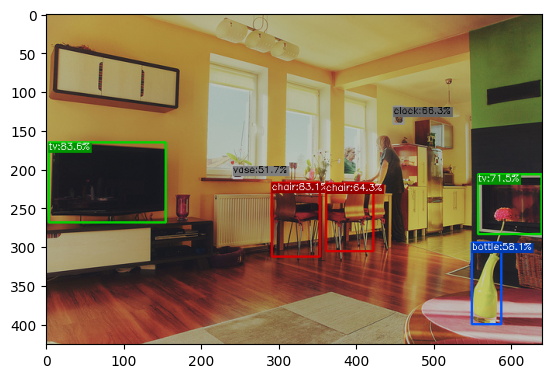

In [9]:
from damo.utils import get_model_info, vis, postprocess
conf = 0.5
config = parse_config(config_path)
image = cv2.cvtColor(cv2.imread(n), cv2.COLOR_BGR2RGB)
vis_res = vis(image, bb, sc, cl, conf, config.dataset.class_names)
plt.imshow(vis_res)

## Continue

In [10]:
# for name, layer in list(model.named_modules())[:1]:
#     print(name, layer)

In [11]:
# data = [(layer, str(embeddings[0].shape), str(embeddings[1].shape)) for layer, embeddings in fms.items()]
# print(tabulate(data, headers=["Слой", "Размер входа", "Размер выхода"], tablefmt="grid"))

In [12]:
import torch.nn.functional as F

def pairwise_cosine_similarity(x1, x2):
    x1 = F.normalize(x1, dim=0)
    x2 = F.normalize(x2, dim=0)
    return x1.T @ x2

In [13]:
def e(f, s):
    return torch.norm(f - s)

In [20]:
kernel_size_is_1_ = False

In [21]:
conv = {}

if kernel_size_is_1_:
    convolution = model.backbone.block_list[3].block_list[0].conv1.conv1
    bn = model.backbone.block_list[3].block_list[0].conv1.bn1

    conv['before conv'] = list(fms.values())[0][0]
    conv['after conv']  = list(fms.values())[0][1]
    signal_after_bn_true_ = list(fms.values())[1][1]
else:
    convolution = model.backbone.block_list[3].block_list[0].conv2.rbr_dense.conv
    bn = model.backbone.block_list[3].block_list[0].conv2.rbr_dense.bn

    conv['before conv'] = list(fms.values())[2][0]
    conv['after conv']  = list(fms.values())[2][1]
    signal_after_bn_true_ = list(fms.values())[3][1]

center = bn.running_mean

W = convolution.weight.data
W_eff = W.view(W.size()[0], W.size()[1], -1).sum(dim=2)  # shape: [out_ch, in_ch]
W_pinv = torch.pinverse(W_eff)

center_before_conv = W_pinv @ center
# batch_center_before_conv  = conv['before conv'].mean(dim=(0, 2, 3))
# batch_center_through_conv = W_eff @ batch_center_before_conv
# batch_center_after_conv   = conv['after conv'].mean(dim=(0, 2, 3)).squeeze()

In [16]:
# TESTS for 1x1

signal = conv['before conv']
signal_after_conv_true = convolution(signal)
signal_after_bn_true = bn(signal_after_conv_true)

# signal_after_center = signal_after_conv - center.view(1, -1, 1, 1)
# signal_after_norm = signal_after_center / torch.sqrt(bn.running_var.view(1, -1, 1, 1) + bn.eps)
# signal_after_bn_selfmade = signal_after_norm * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

# print(torch.norm(signal_after_bn - signal_after_bn_selfmade)) # 4e-4

signal_after_center = signal - center_before_conv.view(1, -1, 1, 1)
signal_after_conv = convolution(signal_after_center)
signal_after_norm = signal_after_conv / torch.sqrt(bn.running_var.view(1, -1, 1, 1) + bn.eps)
signal_after_bn = signal_after_norm * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

e(signal_after_bn,
  signal_after_bn_true_) # 6e-3

forward hook used
forward hook used
forward hook used


tensor(0.0056, device='cuda:0', grad_fn=<CopyBackwards>)

In [19]:
print('1st operation loss: ', e(convolution(signal - center_before_conv.view(1, -1, 1, 1)),
                                convolution(signal) - convolution(center_before_conv.view(1, -1, 1, 1))))
print('inv center loss: ', e(convolution(center_before_conv.view(1, -1, 1, 1)),
                             center.view(1, -1, 1, 1)))
print('2nd operation loss: ', e(convolution(signal) - convolution(center_before_conv.view(1, -1, 1, 1)),
                                convolution(signal) - center.view(1, -1, 1, 1)))
print('total loss: ', e(convolution(signal - center_before_conv.view(1, -1, 1, 1)),
                        convolution(signal) - center.view(1, -1, 1, 1)))

forward hook used
forward hook used
forward hook used
1st operation loss:  tensor(0.0003, device='cuda:0', grad_fn=<CopyBackwards>)
forward hook used
inv center loss:  tensor(1.9414e-06, device='cuda:0', grad_fn=<CopyBackwards>)
forward hook used
forward hook used
forward hook used
2nd operation loss:  tensor(0.0012, device='cuda:0', grad_fn=<CopyBackwards>)
forward hook used
forward hook used
total loss:  tensor(0.0013, device='cuda:0', grad_fn=<CopyBackwards>)


In [18]:
torch.norm(signal), torch.norm(convolution(signal)), torch.norm(center), torch.norm(center_before_conv)

forward hook used


(tensor(7441.5879, device='cuda:0'),
 tensor(1602.6787, device='cuda:0', grad_fn=<CopyBackwards>),
 tensor(1.3717, device='cuda:0'),
 tensor(7.7698, device='cuda:0'))

In [22]:
# TESTS for 3x3

signal = conv['before conv']
signal_after_conv_true = convolution(signal)
signal_after_bn_true = bn(signal_after_conv_true)

# signal_after_center = signal_after_conv - center.view(1, -1, 1, 1)
# signal_after_norm = signal_after_center / torch.sqrt(bn.running_var.view(1, -1, 1, 1) + bn.eps)
# signal_after_bn_selfmade = signal_after_norm * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

# print(torch.norm(signal_after_bn - signal_after_bn_selfmade)) # 4e-4

signal_after_center = signal - center_before_conv.view(1, -1, 1, 1)
signal_after_conv = convolution(signal_after_center)
signal_after_norm = signal_after_conv / torch.sqrt(bn.running_var.view(1, -1, 1, 1) + bn.eps)
signal_after_bn = signal_after_norm * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

e(signal_after_bn,
  signal_after_bn_true_) # 200

forward hook used
forward hook used
forward hook used


tensor(208.6609, device='cuda:0', grad_fn=<CopyBackwards>)

In [23]:
print('1st operation loss: ', e(convolution(signal - center_before_conv.view(1, -1, 1, 1)),
                                convolution(signal) - convolution(center_before_conv.view(1, -1, 1, 1))))
print('inv center loss: ', e(convolution(center_before_conv.view(1, -1, 1, 1)),
                             center.view(1, -1, 1, 1)))
print('2nd operation loss: ', e(convolution(signal) - convolution(center_before_conv.view(1, -1, 1, 1)),
                                convolution(signal) - center.view(1, -1, 1, 1)))
print('total loss: ', e(convolution(signal - center_before_conv.view(1, -1, 1, 1)),
                        convolution(signal) - center.view(1, -1, 1, 1)))

forward hook used
forward hook used
forward hook used
1st operation loss:  tensor(404.9382, device='cuda:0', grad_fn=<CopyBackwards>)
forward hook used
inv center loss:  tensor(1.2711, device='cuda:0', grad_fn=<CopyBackwards>)
forward hook used
forward hook used
forward hook used
2nd operation loss:  tensor(406.7643, device='cuda:0', grad_fn=<CopyBackwards>)
forward hook used
forward hook used
total loss:  tensor(41.7307, device='cuda:0', grad_fn=<CopyBackwards>)


In [24]:
torch.norm(signal), torch.norm(convolution(signal)), torch.norm(center), torch.norm(center_before_conv)

forward hook used


(tensor(3339.0386, device='cuda:0'),
 tensor(989.4926, device='cuda:0', grad_fn=<CopyBackwards>),
 tensor(1.6026, device='cuda:0'),
 tensor(2.3355, device='cuda:0'))

---

In [ ]:
# print(torch.linalg.norm(W_eff @ W_pinv).cpu())
# print(torch.linalg.norm(torch.eye(W_eff.size()[1])))


tensor(9.7980)
tensor(9.7980)


In [31]:
print(pairwise_cosine_similarity(batch_center_before_conv, center_before_conv))
print(pairwise_cosine_similarity(batch_center_through_conv, center))
print(pairwise_cosine_similarity(batch_center_through_conv, batch_center_after_conv))

tensor(0.9829, device='cuda:0')
tensor(0.9809, device='cuda:0')
tensor(0.9995, device='cuda:0')


In [52]:
print(torch.linalg.norm(batch_center_before_conv  - center_before_conv))
print(torch.linalg.norm(batch_center_through_conv - center))
print(torch.linalg.norm(batch_center_through_conv - batch_center_after_conv))

tensor(0.4311, device='cuda:0')
tensor(0.3249, device='cuda:0')
tensor(0.0544, device='cuda:0')


In [53]:
print(torch.linalg.norm(center_before_conv))
print(torch.linalg.norm(batch_center_before_conv))
print(torch.linalg.norm(batch_center_through_conv))
print(torch.linalg.norm(center))
print(torch.linalg.norm(batch_center_after_conv))

tensor(2.3355, device='cuda:0')
tensor(2.2604, device='cuda:0')
tensor(1.6626, device='cuda:0')
tensor(1.6026, device='cuda:0')
tensor(1.6484, device='cuda:0')
